# LAB Entrena y ajusta tu red neuronal #

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from scikeras.wrappers import KerasRegressor
import random
import os
tf.keras.utils.set_random_seed(42)
# Fijar semillas
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)


**Cargar datos**

In [2]:
data = load_diabetes()
X = data.data
y = data.target

**Train / Test split**

In [3]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("División de datos completada.")
print(f"Muestras de Entrenamiento: {X_train.shape[0]} (80%)")
print(f"Muestras de Validación:    {X_val.shape[0]} (20%)")

División de datos completada.
Muestras de Entrenamiento: 353 (80%)
Muestras de Validación:    89 (20%)


**Escalar datos**

In [4]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

**Modelo Base**

El primer modelo de red neuronal que se construyó, denominado 'Baseline', es un modelo secuencial de Keras diseñado para una tarea de regresión.

**Arquitectura del Modelo: El modelo consta de tres capas densas (Dense):**

**Primera Capa (Capa Oculta):**
- Contiene **32 neuronas**.
- Utiliza la función de activación **ReLU** (activation='relu'). ReLU (Rectified Linear Unit) es una función de activación popular que ayuda a la red a aprender patrones complejos y a mitigar el problema del gradiente desvanecido.

**Segunda Capa (Capa Oculta):**
- Contiene **16 neuronas**.
- También utiliza la función de activación **ReLU**.

**Tercera Capa (Capa de Salida):**
- Contiene **1 neurona**
- No tiene función de activación especificada

**Optimizador:** Se utiliza el optimizador **'adam'** (optimizer='adam'). Adam es un algoritmo de optimización eficiente y popular que ajusta dinámicamente las tasas de aprendizaje para cada peso de la red, lo que lo hace adecuado para una amplia gama de problemas.

In [5]:
def create_model(neurons1=32, neurons2=16, learning_rate=0.001):
    model = keras.Sequential([
        keras.Input(shape=(X_train.shape[1],)),
        layers.Dense(neurons1, activation="relu"),
        layers.Dense(neurons2, activation="relu"),
        layers.Dense(1)
    ])
    
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    
    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )
    
    return model

**Se entrena modelo base**

batch= 16
Epochs= 60

In [6]:
model = create_model()

history = model.fit(
    X_train, y_train,
    epochs=60,
    batch_size=16,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 29703.6289 - mae: 153.7863 - val_loss: 26487.8320 - val_mae: 145.6074
Epoch 2/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 29485.1191 - mae: 153.1369 - val_loss: 26293.3477 - val_mae: 145.0021
Epoch 3/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 29234.2090 - mae: 152.4202 - val_loss: 26052.0332 - val_mae: 144.2718
Epoch 4/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 28907.1152 - mae: 151.5038 - val_loss: 25728.5312 - val_mae: 143.3019
Epoch 5/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 28459.5957 - mae: 150.2538 - val_loss: 25282.0371 - val_mae: 141.9723
Epoch 6/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 27830.8672 - mae: 148.4928 - val_loss: 24645.9980 - val_mae: 140.0863
Epoch 7/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 26946.5020 - mae: 145.9947 - val_loss: 23760.3672 - val_mae: 137.4445
Epoch 8/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 25748.6875 - mae: 142.5495 - val_loss:

**Evalúo modelo base**

In [7]:
y_pred = model.predict(X_val).ravel()

mae = mean_absolute_error(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_pred)

print("MODELO BASE")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
MODELO BASE
MAE:  44.7434
RMSE: 55.3608
R²:   0.4215


**Gráfica modelo base (para comparativas)**

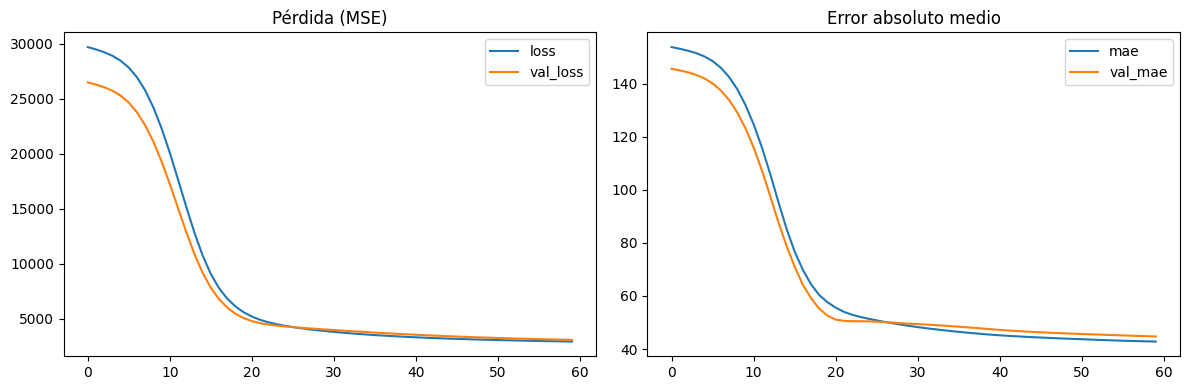

In [8]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Pérdida (MSE)")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["mae"], label="mae")
plt.plot(history.history["val_mae"], label="val_mae")
plt.title("Error absoluto medio")
plt.legend()

plt.tight_layout()
plt.show()


**Se modifican algunos hiperparámetros del modelo (capas, neuronas, batch size, epochs, etc.) y se observa cómo cambian los resultados**

Se realiza una búsqueda preliminar sin una técnica específica, sino dándole distintas configuraciones para ver cómo va cambiando especificamente la métrica MAE de evaluación.

In [9]:
from tensorflow import keras
from tensorflow.keras import layers

# Configuraciones a probar (incluye learning rate)
configuraciones = [
    {'neurons1': 32, 'neurons2': 16, 'batch': 16},
    {'neurons1': 64, 'neurons2': 32, 'batch': 16},
    {'neurons1': 32, 'neurons2': 16, 'batch': 8},
    {'neurons1': 64, 'neurons2': 16, 'batch': 32},
    {'neurons1': 64, 'neurons2': 32, 'batch': 16},
    {'neurons1': 32, 'neurons2': 16, 'batch': 16}
]

mejor_mae = float('inf')
mejor_config = None

print("Iniciando búsqueda manual de hiperparámetros...")

for config in configuraciones:
    
    print(f"\nProbando: N1={config['neurons1']}, N2={config['neurons2']} - Batch={config['batch']}")

    # Crear modelo
    model_temp = keras.Sequential([
        keras.Input(shape=(X_train.shape[1],)),
        layers.Dense(config['neurons1'], activation="relu"),
        layers.Dense(config['neurons2'], activation="relu"),
        layers.Dense(1)
    ])

    # Compilar con learning rate variable
    model_temp.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"]
    )

    # Entrenar (pocas epochs para comparar rápido)
    model_temp.fit(
        X_train, y_train,
        epochs=50,
        batch_size=config['batch'],
        verbose=0
    )

    # Evaluar
    loss, mae = model_temp.evaluate(X_val, y_val, verbose=0)

    print(f" > MAE obtenido: {mae:.4f}")

    # Guardar mejor configuración
    if mae < mejor_mae:
        mejor_mae = mae
        mejor_config = config

print("\n--- BÚSQUEDA FINALIZADA ---")
print(f"Mejor configuración: {mejor_config}")
print(f"Mejor MAE: {mejor_mae:.4f}")

Iniciando búsqueda manual de hiperparámetros...

Probando: N1=32, N2=16 - Batch=16
 > MAE obtenido: 44.3061

Probando: N1=64, N2=32 - Batch=16
 > MAE obtenido: 43.0938

Probando: N1=32, N2=16 - Batch=8
 > MAE obtenido: 42.8674

Probando: N1=64, N2=16 - Batch=32
 > MAE obtenido: 48.2133

Probando: N1=64, N2=32 - Batch=16
 > MAE obtenido: 43.1815

Probando: N1=32, N2=16 - Batch=16
 > MAE obtenido: 45.4170

--- BÚSQUEDA FINALIZADA ---
Mejor configuración: {'neurons1': 32, 'neurons2': 16, 'batch': 8}
Mejor MAE: 42.8674


La búsqueda preliminar indica que la mejor configuración de RNA para este caso sería de (n1= 32, n2= 16) con batch size de 8. Sin embargo existen otros hiperparámetros que deben considerarse como el número de épocas y tasa de aprendizaje, que necesita el modelo para que aprenda bien los datos.

**Se realiza búsqueda manual de hiperparámetros pero observando la evolución de las métricas en el entrenamiento**

**Se inicia una lista para comparar resultados**

In [10]:
resultados = []

**Función auxiliar para probar modelos**

In [11]:
def entrenar_y_evaluar(nombre_modelo, neurons1, neurons2, lr, epochs, batch_size):
    
    model = create_model(neurons1=neurons1, neurons2=neurons2, learning_rate=lr)
    
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_val, y_val),
        verbose=0
    )
    
    y_pred = model.predict(X_val).ravel()
    
    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    r2 = r2_score(y_val, y_pred)
    
    resultados.append([nombre_modelo, neurons1, neurons2, lr, epochs, batch_size, mae, rmse, r2])
    
    print(f"\n🔹 {nombre_modelo}")
    print(f"MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")
    
    return history

**Se realizan experimentos con diferentes valores de hiperparámetros**

**1. Modelo base**

In [12]:
entrenar_y_evaluar(
    "Base",
    neurons1=32,
    neurons2=16,
    lr=0.001,
    epochs=60,
    batch_size=16
)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step

🔹 Base
MAE: 44.0465 | RMSE: 55.2829 | R2: 0.4232


**2. Más neuronas (más complejo)**

In [13]:
entrenar_y_evaluar(
    "Mas neuronas",
    neurons1=64,
    neurons2=32,
    lr=0.001,
    epochs=60,
    batch_size=16
)

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/stepWARNING:tensorflow:6 out of the last 9 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x00000231F6A19940> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step

🔹 Mas neuronas
MAE: 42.7446 | RMSE: 53.0682 | R2: 0.4684


**3. Menos neuronas (más simple)**

In [14]:
entrenar_y_evaluar(
    "Menos neuronas",
    neurons1=16,
    neurons2=8,
    lr=0.001,
    epochs=60,
    batch_size=16
)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step

🔹 Menos neuronas
MAE: 49.2353 | RMSE: 62.8216 | R2: 0.2551


**4. Más epochs**

In [15]:
entrenar_y_evaluar(
    "Mas epochs",
    neurons1=32,
    neurons2=16,
    lr=0.001,
    epochs=150,
    batch_size=16
)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step

🔹 Mas epochs
MAE: 42.0230 | RMSE: 52.2144 | R2: 0.4854


**5. Batch pequeño**

In [16]:
entrenar_y_evaluar(
    "Batch pequeno",
    neurons1=32,
    neurons2=16,
    lr=0.001,
    epochs=60,
    batch_size=8
)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step

🔹 Batch pequeno
MAE: 42.3944 | RMSE: 52.6568 | R2: 0.4767


**6. Batch grande**

In [17]:
entrenar_y_evaluar(
    "Batch grande",
    neurons1=32,
    neurons2=16,
    lr=0.001,
    epochs=60,
    batch_size=32
)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step

🔹 Batch grande
MAE: 49.7666 | RMSE: 63.7381 | R2: 0.2332


**7. Learning rate alto**

In [18]:
entrenar_y_evaluar(
    "LR alto",
    neurons1=32,
    neurons2=16,
    lr=0.01,
    epochs=60,
    batch_size=16
)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step

🔹 LR alto
MAE: 44.5865 | RMSE: 55.1158 | R2: 0.4266


**8. Learning rate bajo**

In [19]:
entrenar_y_evaluar(
    "LR bajo",
    neurons1=32,
    neurons2=16,
    lr=0.0005,
    epochs=60,
    batch_size=16
)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step

🔹 LR bajo
MAE: 42.8636 | RMSE: 53.6709 | R2: 0.4563


**Ver resultados**

In [20]:
import pandas as pd

df_resultados = pd.DataFrame(
    resultados,
    columns=["Modelo", "N1", "N2", "LR", "Epochs", "Batch", "MAE", "RMSE", "R2"]
)

df_resultados.sort_values(by="MAE")

,Modelo,N1,N2,LR,Epochs,Batch,MAE,RMSE,R2
3,Mas epochs,32,16,0.0010,150,16,42.022952,52.214382,0.485416
4,Batch pequeno,32,16,0.0010,60,8,42.394351,52.656835,0.476659
1,Mas neuronas,64,32,0.0010,60,16,42.744610,53.068224,0.468449
7,LR bajo,32,16,0.0005,60,16,42.863633,53.670913,0.456307
0,Base,32,16,0.0010,60,16,44.046476,55.282888,0.423158
6,LR alto,32,16,0.0100,60,16,44.586535,55.115842,0.426639
2,Menos neuronas,16,8,0.0010,60,16,49.235297,62.821646,0.255106
5,Batch grande,32,16,0.0010,60,32,49.766579,63.738065,0.233215


Se realizó una exploración manual de hiperparámetros, observándose que, al aumentar el número de épocas mejoró levemente el rendimiento, mientras que el uso de batch sizes pequeños favoreció la generalización del modelo (R2 mayor).

Por otro lado, modelos con menor cantidad de neuronas presentaron underfitting, evidenciado en un aumento significativo del error, mientras que incrementar la complejidad no generó mejoras sustanciales (respecto al modelo base).

En conjunto, estos resultados permitieron identificar configuraciones más eficientes, las cuales serán utilizadas como base para la optimización mediante RandomizedSearchCV.

**Aplicación de técnica de búsqueda de hiperparámetros:  RandomizedSearch**

Ahora se realiza la búsqueda, con el método RandomizedSearchCV, que permite encontrar de manera eficiente los parámetros óptimos del modelo mediante el muestreo aleatorio de un número fijo de combinaciones de parámetros a partir de distribuciones específicas, en lugar de probar todas las combinaciones posibles. Se utiliza éste considerando que es mucho más rápido que GridSearchCV.

In [21]:
from scikeras.wrappers import KerasRegressor

model_keras = KerasRegressor(
    model=create_model,
    verbose=0
)

param_dist = {
    "model__neurons1": [16, 32, 64],
    "model__neurons2": [8, 16, 32],
    "batch_size": [8, 16, 32],
    "epochs": [50, 80, 100, 200],
    "model__learning_rate": [0.01, 0.001, 0.0005]
}

random_search = RandomizedSearchCV(
    estimator=model_keras,
    param_distributions=param_dist,
    n_iter=10,
    scoring="neg_mean_absolute_error",
    cv=3,
    verbose=0,
    random_state=42
)

random_search.fit(X_train, y_train)

print("MEJORES HIPERPARÁMETROS")
print(random_search.best_params_)

MEJORES HIPERPARÁMETROS
{'model__neurons2': 16, 'model__neurons1': 64, 'model__learning_rate': 0.01, 'epochs': 200, 'batch_size': 16}


**Modelo optimizado con RandomSearch**

In [22]:
best_model = random_search.best_estimator_

In [23]:
model_final = best_model.model_

**Arquitectura del Modelo 'optimizado':**
Tiene una arquitectura de red neuronal que incluye dos  capas Dense ocultas y una capa de salida:

- **Primera capa oculta:** Dense(64, activation='relu'). Esta capa tiene 64 neuronas y utiliza la función de activación relu. También define la forma de entrada para el modelo.

- **Segunda capa oculta:** Dense(16, activation='relu'). Contiene 16 neuronas con activación relu.

- **Capa de salida:** Dense(1). Una única neurona con activación lineal (por defecto, adecuada para regresión)


**Reentrenamos el modelo optimizado**

Se entrena el modelo optimizado, con el fin de permitir que la red convergiera adecuadamente:

**Épocas:** epochs=200. Según la optimización realizada, se aumentó el número de épocas de 60 a 200 lo que le da al modelo más oportunidades de aprender de los datos.

**Tamaño del Batch:** batch_size=16. Se procesaron los datos en lotes de 16 muestras antes de actualizar los pesos del modelo.

**Learning rate:** Learning_rate=0.01. En este caso el método seleccionó una mayor a la del modelo base, lo que indica que el ritmo al que el algoritmo actualiza los pesos del modelo es mayor.

**Verbosity:** verbose=1. Se activó la salida detallada durante el entrenamiento para observar el progreso por época.

In [24]:
history_opt = model_final.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=best_model.get_params()["epochs"],
    batch_size=best_model.get_params()["batch_size"],
    verbose=1
)

Epoch 1/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 2358.8457 - mae: 38.4729 - val_loss: 2716.5215 - val_mae: 41.3832
Epoch 2/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2357.1924 - mae: 38.4565 - val_loss: 2716.7053 - val_mae: 41.3816
Epoch 3/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 2355.1389 - mae: 38.4355 - val_loss: 2717.1917 - val_mae: 41.3820
Epoch 4/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 2353.8013 - mae: 38.4210 - val_loss: 2717.1353 - val_mae: 41.3806
Epoch 5/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 2351.7366 - mae: 38.4053 - val_loss: 2717.9827 - val_mae: 41.3719
Epoch 6/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2350.4075 - mae: 38.3914 - val_loss: 2716.1975 - val_mae: 41.3716
Epoch 7/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2348.5139 - mae: 38.3749 - val_loss: 2720.3252 - val_mae: 41.3791
Epoch 8/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2347.2036 - mae: 38.3615 - val_loss: 2717.4915 - val_mae: 

Se observa que con las épocas el modelo se ajusta mejor, sin embargo, no en gran medida, esto se puede comprobar viendo la función de pérdida desde la época 12 a la 200 y la variación del MAE entre estas dos épocas, por lo que podríamos decir que el modelo no necesita tantas épocas para ajustarse. Además, se puede observar la diferencia entre los valores de entrenamiento y validación, y así también se observa como la pérdida en validación aumentó, lo que podría indicar que el modelo no generaliza bien.

**Evaluación final**

In [25]:
y_pred_opt = best_model.predict(X_val)

mae = mean_absolute_error(y_val, y_pred_opt)
mse = mean_squared_error(y_val, y_pred_opt)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_pred_opt)

print("\n🔹 MODELO OPTIMIZADO")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")


🔹 MODELO OPTIMIZADO
MAE:  41.3006
RMSE: 53.5682
R²:   0.4584


Para la selección del mejor modelo se priorizaron métricas de error como MAE y RMSE, dado que permiten evaluar directamente la precisión de las predicciones. El coeficiente R² se utilizó como métrica complementaria para analizar la capacidad explicativa del modelo.

En este contexto, el modelo optimizado mediante RandomizedSearchCV presentó el mejor desempeño global, superando tanto al modelo base como a las configuraciones evaluadas manualmente. **Esto considerando solo las métricas evaluadas.**

**Gráfica entrenamiento**

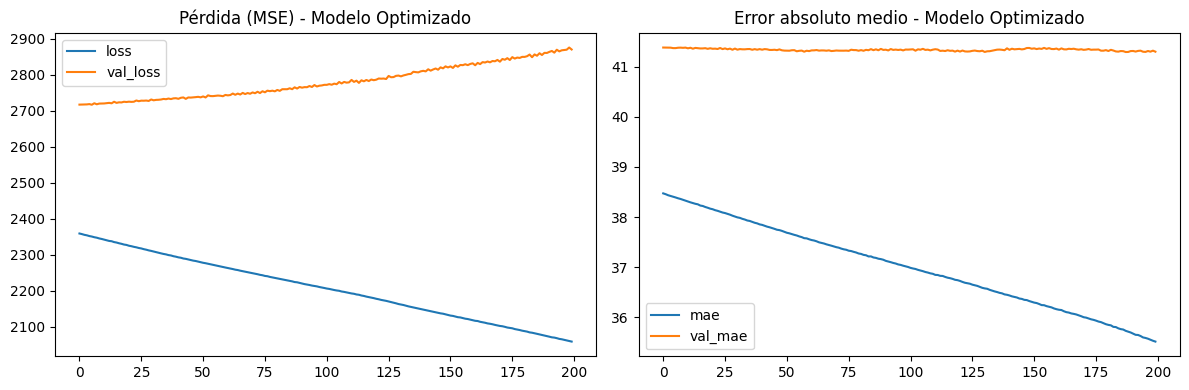

In [26]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_opt.history["loss"], label="loss")
plt.plot(history_opt.history["val_loss"], label="val_loss")
plt.title("Pérdida (MSE) - Modelo Optimizado")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_opt.history["mae"], label="mae")
plt.plot(history_opt.history["val_mae"], label="val_mae")
plt.title("Error absoluto medio - Modelo Optimizado")
plt.legend()

plt.tight_layout()
plt.show()

Las curvas de entrenamiento muestran que el error en el conjunto de entrenamiento disminuye progresivamente, mientras que el error en validación tiende a aumentar. Esto indica la presencia de sobreajuste, donde el modelo aprende patrones específicos del conjunto de entrenamiento pero pierde capacidad de generalización.

En comparación con el modelo inicial, las curvas de entrenamiento del modelo optimizado muestran una disminución más pronunciada del error en el conjunto de entrenamiento. Esto puede deberse al uso de un mayor número de épocas y una tasa de aprendizaje más alta, lo que permite que el modelo aprenda más rápidamente y ajuste mejor los datos de entrenamiento. Sin embargo, este mismo efecto provoca que el modelo continúe ajustándose incluso cuando ya no mejora en el conjunto de validación, generando sobreajuste.

Como recomendación, se sugiere aplicar la técnica de Early Stopping, la cual permite detener el entrenamiento automáticamente cuando el error en validación deja de mejorar. Esto ayuda a evitar el sobreajuste, ya que el modelo se conserva en el punto donde logra el mejor equilibrio entre aprendizaje y capacidad de generalización, mejorando así su desempeño en datos nuevos.

**Comparación visual valores reales vs predichos**

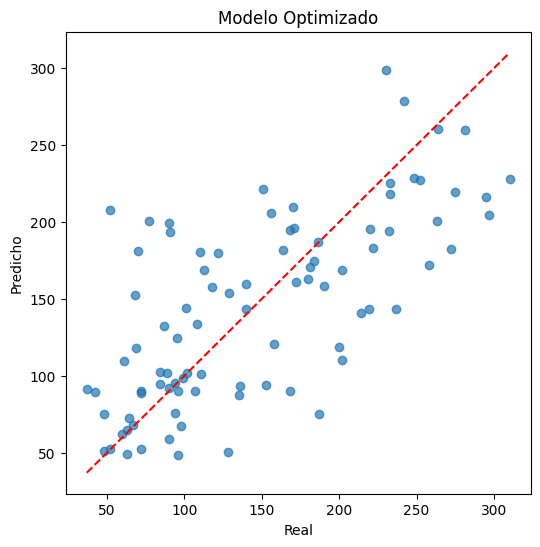

In [27]:
plt.figure(figsize=(6,6))
plt.scatter(y_val, y_pred_opt, alpha=0.7)
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.title("Modelo Optimizado")
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], "r--")
plt.show()

In [28]:
import pandas as pd

# Crear DataFrame con 10 ejemplos
df_comp = pd.DataFrame({
    "Real": y_val[:10],
    "Predicho": y_pred[:10]
})

# Calcular diferencia y error %
df_comp["Diferencia"] = df_comp["Real"] - df_comp["Predicho"]
df_comp["Error %"] = (df_comp["Diferencia"].abs() / df_comp["Real"]) * 100

# Redondear para que se vea más bonito
df_comp = df_comp.round(2)

df_comp


,Real,Predicho,Diferencia,Error %
0,219.0,173.639999,45.36,20.71
1,70.0,180.970001,-110.97,158.52
2,202.0,147.729996,54.27,26.87
3,230.0,333.989990,-103.99,45.21
4,111.0,81.580002,29.42,26.50
5,84.0,120.180000,-36.18,43.07
6,242.0,268.250000,-26.25,10.85
7,272.0,184.520004,87.48,32.16
8,94.0,65.239998,28.76,30.59
9,96.0,69.139999,26.86,27.97


In [29]:
# Promedio de métricas
prom_diferencia = df_comp["Diferencia"].abs().mean()
prom_error_pct = df_comp["Error %"].mean()

print(f"Promedio diferencia absoluta: {prom_diferencia:.2f}")
print(f"Promedio error porcentual: {prom_error_pct:.2f}%")

Promedio diferencia absoluta: 54.95
Promedio error porcentual: 42.24%


En general, se observa que el modelo logra aproximarse a los valores reales en varios casos, aunque presenta diferencias importantes en ciertas observaciones. Por ejemplo, existen predicciones con errores relativamente bajos, como en el caso de valores cercanos a 242, donde la diferencia es de aproximadamente 26 unidades (10.85%), lo que indica un buen ajuste local.

Sin embargo, también se identifican errores elevados, como en el caso de un valor real de 70, donde el modelo predice aproximadamente 181, generando un error porcentual superior al 150%. Este tipo de desviaciones sugiere que el modelo presenta dificultades para generalizar correctamente en algunos rangos de valores.

En términos generales, el modelo tiende tanto a sobreestimar como a subestimar los valores reales, lo que indica la ausencia de un sesgo sistemático claro, pero sí una variabilidad en la precisión de las predicciones.

El promedio de la diferencia absoluta fue de aproximadamente 55 unidades, mientras que el error porcentual promedio alcanzó cerca de 42%, lo que permite tener una visión global del desempeño del modelo a nivel individual de predicciones.

Estos resultados son consistentes con las métricas globales previamente obtenidas (MAE y RMSE), y reflejan que, si bien el modelo presenta una capacidad predictiva aceptable, aún existen observaciones donde el error es considerable, lo cual es esperable en problemas de regresión con datos reales y variabilidad inherente.

**Conclusión**

En términos generales, el modelo optimizado mediante RandomizedSearchCV presentó mejores métricas de evaluación en comparación con el modelo base, evidenciando una disminución en el MAE y el RMSE, así como un aumento en el coeficiente R². Esto sugiere, desde una perspectiva cuantitativa, una mejora en la capacidad predictiva del modelo.

Sin embargo, al analizar el comportamiento del entrenamiento a través de las curvas de pérdida y error, se observa la presencia de sobreajuste, ya que el error en el conjunto de entrenamiento disminuye de forma sostenida, mientras que el error en validación tiende a aumentar o mantenerse sin mejoras significativas. Esto indica que, si bien el modelo optimizado logra ajustarse mejor a los datos de entrenamiento, no necesariamente mejora su capacidad de generalización.

Por lo tanto, es importante complementar la evaluación basada en métricas con un análisis visual del proceso de entrenamiento, ya que este permite identificar comportamientos que no siempre se reflejan en los indicadores numéricos.

Como recomendación, se sugiere incorporar la técnica de Early Stopping, con el fin de detener el entrenamiento en el punto en que el modelo alcanza su mejor desempeño en validación. Esto permitiría reducir el sobreajuste y mejorar la capacidad de generalización, logrando un equilibrio más adecuado entre ajuste y robustez del modelo.